**Imports**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

**Code**

Here we made a variable called "df" inside of it we put the .csv

In [2]:
df = pd.read_csv("cleaned_data.csv")

Here we made a Histplot (with kde) for three different features, 3Ssn Porch (Right skewed), Year Built (Ledt skewed) and Gr Liv Area (Symmetrical)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Library/Frameworks/Python.f

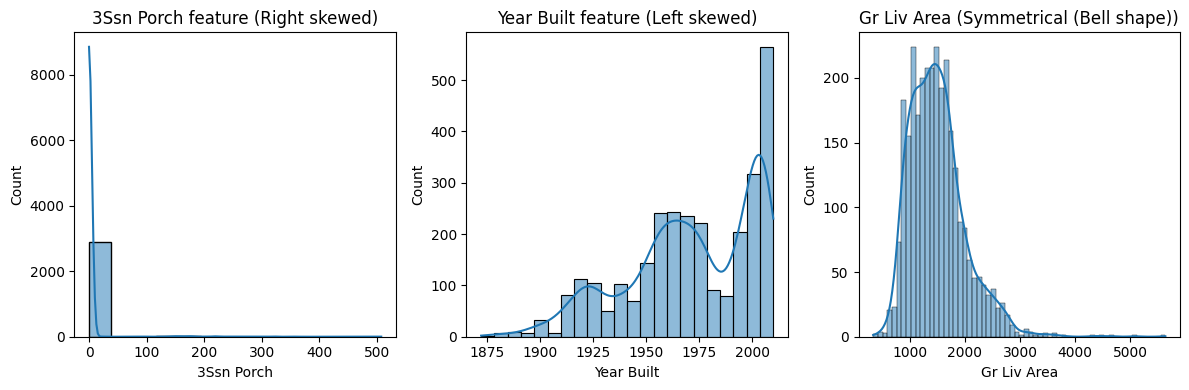

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

sns.histplot(df["3Ssn Porch"], kde = True, ax = axes[0])
axes[0].set_title("3Ssn Porch feature (Right skewed)")

sns.histplot(df["Year Built"], kde = True, ax = axes[1])
axes[1].set_title("Year Built feature (Left skewed)")

sns.histplot(df["Gr Liv Area"], kde = True, ax = axes[2])
axes[2].set_title("Gr Liv Area (Symmetrical (Bell shape))")

plt.tight_layout()
plt.show()

Here we compared how the Overall quality and how the style affect the sale price of the house

/var/folders/rj/0n0zqs0j3m30qjck5w9lh0980000gn/T/ipykernel_14453/3595153622.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = "Overall Qual", y = "SalePrice", data = df, palette = "viridis", ax = axes[0])
/var/folders/rj/0n0zqs0j3m30qjck5w9lh0980000gn/T/ipykernel_14453/3595153622.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = "House Style", y = "SalePrice", data = df, palette = "viridis", ax = axes[1])


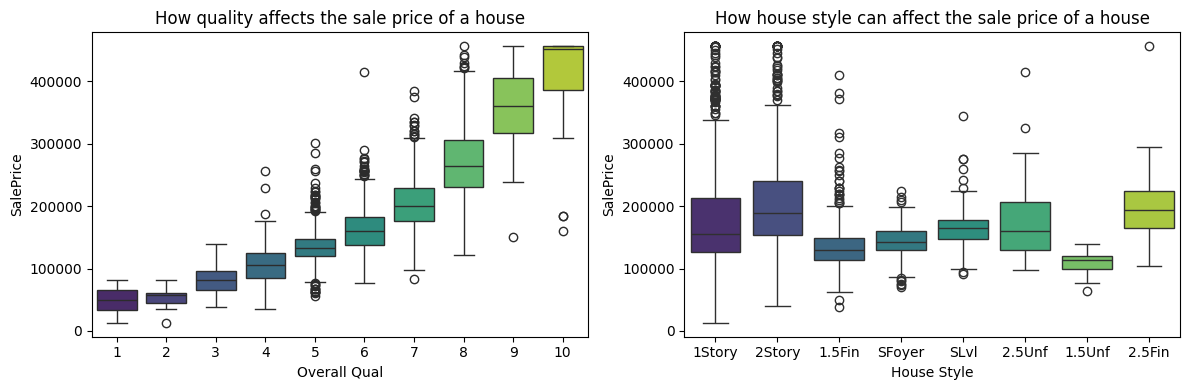

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x = "Overall Qual", y = "SalePrice", data = df, palette = "viridis", ax = axes[0])
axes[0].set_title("How quality affects the sale price of a house")

sns.boxplot(x = "House Style", y = "SalePrice", data = df, palette = "viridis", ax = axes[1])
axes[1].set_title("How house style can affect the sale price of a house")

plt.tight_layout()
plt.show()

Here we made a correlation heatmap that gets the top ten most features the correlate the most with the Screen Porch feature
(The sources : Reddit (https://www.reddit.com/r/learnmachinelearning/comments/9pxg3k/how_can_i_find_strongly_correlated_features_in/, found a way on how to do the task in minotaurohomunculus's comment) + Google Gemini : I had a value error and I didnt understand why I had it, the problem was one row had the value "RL")

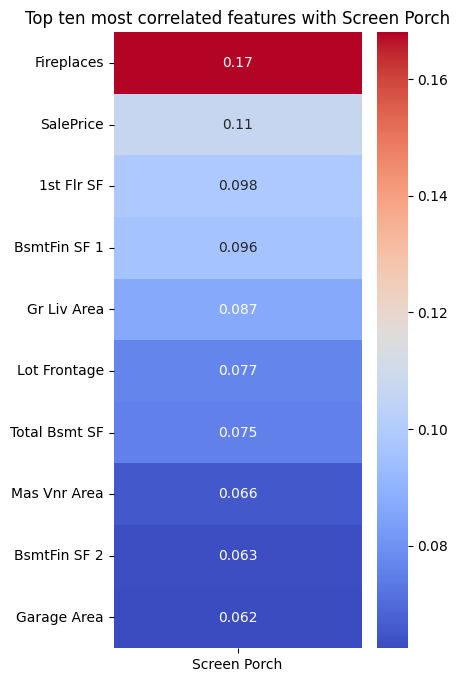

In [5]:
corr = df.corr(numeric_only=True)[["Screen Porch"]].sort_values(by= "Screen Porch", ascending=False).iloc[1:11]

plt.figure(figsize=(4, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Top ten most correlated features with Screen Porch")
plt.show()

Here we made a scatter plot to give you the most information packed into one picture, this picture shows how garage area affects the sale price and the colors show how many cars are in the garage so we know that for example i have a 500m area garage has 2 cars, last but not least the quality of the garage, the bigger the dot the better the garage

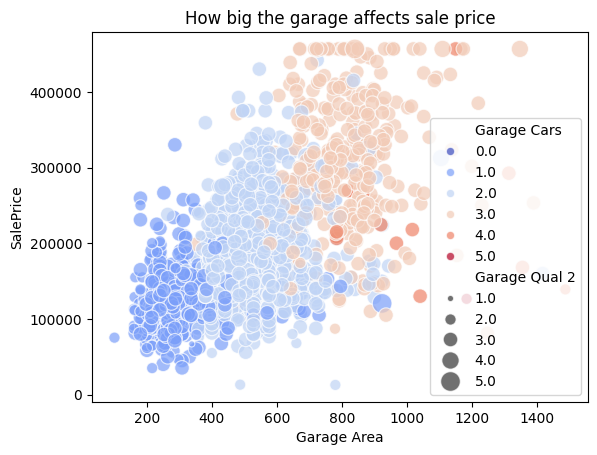

In [6]:
quality_map = {"Ex" : 5, "Gd" : 4, "TA" : 3, "Fa" : 2, "Po" : 1}
df["Garage Qual 2"] = df["Garage Qual"].map(quality_map)
sns.scatterplot(data = df, x = "Garage Area", y = "SalePrice", hue = "Garage Cars", size = "Garage Qual 2", sizes = (20,200),palette = "coolwarm", alpha = 0.7)
plt.title("How big the garage affects sale price")
plt.show()

Here the output shows each groups average (mean) sale price and shows the highest and lowest mean which are H : Gd, L : Po (Used Google gemini because I couldn't find a way to also print the values of the mean not just Po and Gd (the number after the dollar sign "$"))

In [7]:
means = df.groupby("Garage Qual")["SalePrice"].mean().sort_values(ascending = False)
print(means)

highest_group = means.index[0]
highest_value = means.iloc[0]

lowest_group = means.index[-1]
lowest_value = means.iloc[-1]

print(f"Highest mean : '{highest_group}' at ${highest_value:,.2f}")
print(f"Lowest mean : '{lowest_group}' at ${lowest_value:,.2f}")

Garage Qual
Gd    237386.780833
Ex    234888.790000
TA    187009.395025
Fa    117816.822581
Po     88880.000000
Name: SalePrice, dtype: float64
Highest mean : 'Gd' at $237,386.78
Lowest mean : 'Po' at $88,880.00


Write a 1-paragraph insight for each chart (what does it tell us?)